# Centralidades de Hubs y Autoridad

Son los personajes de Star Wars: Episode II - Attack of the Clones, conectados si comparten escenas; las aristas tienen pesos igual a la cantidad de escenas que comparten.

In [16]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display
import matplotlib
from matplotlib import colors as mcolors

pio.renderers.default = "vscode"
plt.set_cmap("rainbow")

<Figure size 640x480 with 0 Axes>

In [17]:
folder = Path("data/dataverse/gexf")
movie_id = 774
fp = folder / f"{movie_id}.gexf"

G = nx.read_gexf(fp, node_type=int)
print("loaded", movie_id, "| Nodos:", G.number_of_nodes(),
      "| Aristas:", G.number_of_edges())

loaded 774 | Nodos: 47 | Aristas: 148


In [18]:
def relabel_nodes_from_attr(
    G: nx.Graph,
    *,
    attr: str = "label",
    fallback_to_id: bool = True,
    make_unique: bool = True,
    copy: bool = True,
) -> nx.Graph:
    """
    Renombra nodos usando G.nodes[n][attr] (p.ej. 'label').
    - make_unique=True agrega sufijos ' (#2)' si hay nombres repetidos.
    """
    base_names = {}
    for n, d in G.nodes(data=True):
        name = d.get(attr)
        if name in (None, "") and fallback_to_id:
            name = str(n)
        base_names[n] = str(name)

    if make_unique:
        counts = {}
        mapping = {}
        for n, nm in base_names.items():
            k = counts.get(nm, 0) + 1
            counts[nm] = k
            mapping[n] = nm if k == 1 else f"{nm} (#{k})"
    else:
        mapping = base_names

    return nx.relabel_nodes(G, mapping, copy=copy)


G1 = relabel_nodes_from_attr(G, attr="label", make_unique=True, copy=True)

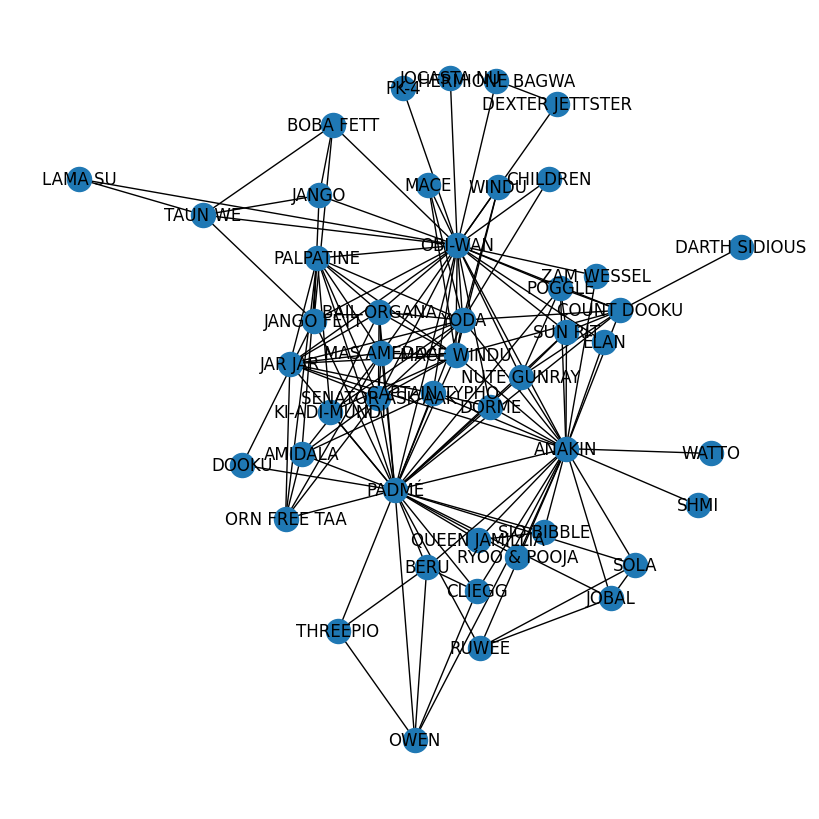

In [19]:
plt.figure(figsize=[8, 8])
layout = nx.kamada_kawai_layout(G1)
nx.draw(G1, layout, with_labels=True)

# Actividad


In [20]:
def safe_katz_centrality(G, alpha=0.5, step=0.01):
    while alpha > 0:
        try:
            return nx.katz_centrality(G, alpha=alpha), alpha
        except Exception:
            alpha -= step

    raise ValueError("Katz centrality did not converge for any positive alpha.")

deg_centralidades = nx.degree_centrality(G1)
eig_centralidades = nx.eigenvector_centrality(G1)
katz_centralidades, katz_alpha = safe_katz_centrality(G1, alpha=0.09)
print(f"Convergio con un alpha={katz_alpha:.4f}")
pg_centralidades = nx.pagerank(G1)
hubs_centralidades, auth_centralidades = nx.hits(G1)
clos_centralidades = nx.closeness_centrality(G1)
btw_centralidades = nx.betweenness_centrality(G1)


def sum1_dict(d):
    s = sum(abs(v) for v in d.values())
    return {k: (v / s if s != 0 else 0.0) for k, v in d.items()}


deg_centralidades = sum1_dict(deg_centralidades)
eig_centralidades = sum1_dict(eig_centralidades)
katz_centralidades = sum1_dict(katz_centralidades)
pg_centralidades = sum1_dict(pg_centralidades)
hubs_centralidades = sum1_dict(hubs_centralidades)
auth_centralidades = sum1_dict(auth_centralidades)
clos_centralidades = sum1_dict(clos_centralidades)
btw_centralidades = sum1_dict(btw_centralidades)


eig_sizes = np.array([eig_centralidades[n] for n in G1])
deg_colors = np.array([deg_centralidades[i] for i in G1])
pg_sizes = np.array([pg_centralidades[n] for n in G1])
katz_colors = np.array([katz_centralidades[i] for i in G1])
hubs_colors = np.array([hubs_centralidades[i] for i in G1])
auth_colors = np.array([auth_centralidades[i] for i in G1])
clos_colors = np.array([clos_centralidades[i] for i in G1])
btw_colors = np.array([btw_centralidades[i] for i in G1])

metrics = {
    "Degree": np.asarray(deg_colors, dtype=float),
    "Eigenvector": np.asarray(eig_sizes, dtype=float),
    "Katz": np.asarray(katz_colors, dtype=float),
    "PageRank": np.asarray(pg_sizes, dtype=float),
    "Hubs": np.asarray(hubs_colors, dtype=float),
    "Authorities": np.asarray(auth_colors, dtype=float),
    "Closeness": np.asarray(clos_colors, dtype=float),
    "Betweenness": np.asarray(btw_colors, dtype=float),
}

Convergio con un alpha=0.0800


In [21]:
k = 10

top_deg = [n for n, v in sorted(
    deg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_eig = [n for n, v in sorted(
    eig_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_katz = [n for n, v in sorted(
    katz_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_pg = [n for n, v in sorted(
    pg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_hubs = [n for n, v in sorted(
    hubs_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_auth = [n for n, v in sorted(
    auth_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_clos = [n for n, v in sorted(
    clos_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_btw = [n for n, v in sorted(
    btw_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]

In [22]:
def plot_network(
    G,
    metrics,
    metric="Degree",
    topk=10,
    largest_first=True,
    layout="kamada_kawai",
    colorscale="Turbo",
    renderer="vscode",   # or "notebook_connected"
    interactive=False,   # default static
):
    nodes = list(G.nodes())
    N = len(nodes)

    # Validate and normalize metrics
    m = {}
    for name, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{name}' has length {len(a)} but graph has {N} nodes.")
        m[name] = a

    if metric not in m:
        raise ValueError(f"`metric` must be one of: {list(m.keys())}")

    # Fixed layout
    pos = nx.spring_layout(G, seed=7) if layout == "spring" else nx.kamada_kawai_layout(G)

    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    # Edges
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    # Arrow annotations for directed graphs
    directed_annotations = []
    if G.is_directed():
        span = max(node_x.max() - node_x.min(), node_y.max() - node_y.min())
        pad = 0.02 * span if span > 0 else 0.03

        for u, v in G.edges():
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            L = np.hypot(dx, dy)
            if L == 0:
                continue

            ux, uy = dx / L, dy / L
            ax = x0 + ux * pad
            ay = y0 + uy * pad
            xh = x1 - ux * pad
            yh = y1 - uy * pad

            directed_annotations.append(dict(
                x=xh, y=yh, ax=ax, ay=ay,
                xref="x", yref="y", axref="x", ayref="y",
                text="", showarrow=True,
                arrowhead=3, arrowsize=1.0, arrowwidth=1.0,
                arrowcolor="rgba(95,110,130,0.55)"
            ))

    global_max = max(arr.max() for arr in m.values())

    # Hover with all metrics for each node
    all_hover = []
    metric_order = list(m.keys())
    for i, n in enumerate(nodes):
        lines = [f"<b>{n}</b>"]
        for metric_name in metric_order:
            lines.append(f"{metric_name}: {m[metric_name][i]:.4f}")
        all_hover.append("<br>".join(lines))

    def topk_mask(vals, k, largest=True):
        k = max(1, min(int(k), len(vals)))
        idx = np.argsort(vals)
        pick = idx[-k:] if largest else idx[:k]
        mask = np.zeros(len(vals), dtype=bool)
        mask[pick] = True
        return mask

    def build_fig(metric_name, k, largest):
        vals = m[metric_name]
        mask = topk_mask(vals, k, largest)

        vmin, vmax = vals.min(), vals.max()
        sizes = 16 + 34 * (vals - vmin) / (vmax - vmin + 1e-12)
        order_txt = "largest to smallest" if largest else "smallest to largest"

        fig = go.Figure()

        # edges
        fig.add_trace(go.Scatter(
            x=edge_x, y=edge_y, mode="lines",
            line=dict(width=0.8, color="rgba(95,110,130,0.35)"),
            hoverinfo="none", showlegend=False
        ))

        # non-top-k
        fig.add_trace(go.Scatter(
            x=node_x[~mask], y=node_y[~mask],
            mode="markers+text",
            text=[str(n) for n, keep in zip(nodes, mask) if not keep],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#7A8797"),
            hovertext=[h for h, keep in zip(all_hover, mask) if not keep],
            hoverinfo="text",
            marker=dict(
                size=sizes[~mask],
                color="#D9DEE5",
                opacity=0.45,
                line=dict(width=1.8, color="white"),
            ),
            showlegend=False
        ))

        # top-k
        fig.add_trace(go.Scatter(
            x=node_x[mask], y=node_y[mask],
            mode="markers+text",
            text=[str(n) for n, keep in zip(nodes, mask) if keep],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#1F2937"),
            hovertext=[h for h, keep in zip(all_hover, mask) if keep],
            hoverinfo="text",
            marker=dict(
                size=sizes[mask],
                color=vals[mask],
                colorscale=colorscale,
                cmin=0,
                cmax=global_max,
                opacity=0.98,
                line=dict(width=2.2, color="white"),
                colorbar=dict(
                    title=dict(text=metric_name, side="right", font=dict(family="Helvetica", size=13)),
                    thickness=36,
                    len=0.72,
                    y=0.5,
                    x=1.02,
                    outlinewidth=0,
                    borderwidth=0,
                    bgcolor="rgba(0,0,0,0)",
                    tickfont=dict(family="Helvetica", size=11),
                )
            ),
            showlegend=False
        ))

        fig.update_layout(
            title=dict(
                text=f"<b>Star Wars II: Attack of the Clones</b><br>Top {k} by {metric_name} from {order_txt}",
                font=dict(family="Helvetica", size=24, color="#111827")
            ),
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Helvetica", size=12, color="#334155"),
            margin=dict(l=10, r=130, t=90, b=10),
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            height=740,
            dragmode="pan",
            annotations=directed_annotations if G.is_directed() else [],
        )
        return fig

    # Static by default
    if not interactive:
        fig = build_fig(metric, max(1, min(int(topk), N)), largest_first)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    # Interactive controls
    metric_dd = widgets.Dropdown(
        options=list(m.keys()),
        value=metric,
        description="Metric:",
        layout=widgets.Layout(width="260px")
    )
    k_slider = widgets.IntSlider(
        value=max(1, min(int(topk), N)),
        min=1, max=N, step=1,
        description="Top k:",
        layout=widgets.Layout(width="340px")
    )
    order_btn = widgets.ToggleButtons(
        options=[("Largest first", True), ("Smallest first", False)],
        value=largest_first,
        description="Order:",
        layout=widgets.Layout(width="430px")
    )

    out = widgets.Output()

    def redraw(*_):
        fig = build_fig(metric_dd.value, k_slider.value, order_btn.value)
        out.clear_output(wait=True)
        with out:
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_dd.observe(redraw, names="value")
    k_slider.observe(redraw, names="value")
    order_btn.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_dd, k_slider]), order_btn, out]))
    redraw()


In [23]:
from IPython.display import clear_output
clear_output(wait=True)


In [24]:
# tabla

def tabla(top_pos, digits, optional_col_name = None, optional_col_values = None):
    df = (
        pd.DataFrame({
            "node": top_pos,
            "Degree": [deg_centralidades[n] for n in top_pos],
            "Eigenvector": [eig_centralidades[n] for n in top_pos],
            "Katz": [katz_centralidades[n] for n in top_pos],
            "PageRank": [pg_centralidades[n] for n in top_pos],
            "Hubs": [hubs_centralidades[n] for n in top_pos],
            "Authorities": [auth_centralidades[n] for n in top_pos],
            "Closeness": [clos_centralidades[n] for n in top_pos],
            "Betweenness": [btw_centralidades[n] for n in top_pos],
                **({optional_col_name: optional_col_values} if optional_col_name and optional_col_values else {})
        })
        .reset_index(drop=True)
    )


    display(
        df.style.format(
            {
                "Eigenvector": f"{{:.{digits}f}}",
                "Degree": f"{{:.{digits}f}}",
                "PageRank": f"{{:.{digits}f}}",
                "Katz": f"{{:.{digits}f}}",
                "Hubs": f"{{:.{digits}f}}",
                "Authorities": f"{{:.{digits}f}}",
                "Closeness": f"{{:.{digits}f}}",
                "Betweenness": f"{{:.{digits}f}}",
                    
            }
        )
    )
    return df

In [25]:
def plot_ego(
    G,
    center,
    metrics,
    metric="Degree",
    radius=2,
    max_radius_user=4,
    layout="kamada_kawai",
    seed=7,
    renderer="vscode",
    interactive=False,          # default = static
    show_colored_labels=True,  # new: labels for nodes within current radius
):
    if center not in G:
        raise ValueError(f"{center!r} is not in graph")

    nodes = list(G.nodes())
    N = len(nodes)

    m = {}
    for k, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{k}' has length {len(a)} but graph has {N} nodes.")
        m[k] = a
    if metric not in m:
        raise ValueError(f"`metric` must be one of: {list(m.keys())}")

    all_dist = nx.single_source_shortest_path_length(G, center)
    max_available = max(all_dist.values()) if all_dist else 0
    max_r = int(max(0, min(max_radius_user, max_available)))

    pos = nx.spring_layout(G, seed=seed, iterations=300) if layout == "spring" else nx.kamada_kawai_layout(G)
    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    ex, ey = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ex += [x0, x1, None]
        ey += [y0, y1, None]

    # Arrows if directed
    directed_annotations = []
    if G.is_directed():
        span = max(node_x.max() - node_x.min(), node_y.max() - node_y.min())
        pad = 0.02 * span if span > 0 else 0.03
        for u, v in G.edges():
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            L = np.hypot(dx, dy)
            if L == 0:
                continue
            ux, uy = dx / L, dy / L
            directed_annotations.append(dict(
                x=x1 - ux * pad, y=y1 - uy * pad,
                ax=x0 + ux * pad, ay=y0 + uy * pad,
                xref="x", yref="y", axref="x", ayref="y",
                text="", showarrow=True, arrowhead=3, arrowsize=1.0, arrowwidth=1.0,
                arrowcolor="rgba(70,80,100,0.55)"
            ))

    dist = nx.single_source_shortest_path_length(G, center, cutoff=max_r)

    cmap = matplotlib.colormaps["Blues"]
    if max_r > 0:
        stops = np.linspace(0.95, 0.35, max_r + 1)
        center_color = mcolors.to_hex(cmap(stops[0]))
        blues_by_d = {d: mcolors.to_hex(cmap(stops[d])) for d in range(1, max_r + 1)}
    else:
        center_color = mcolors.to_hex(cmap(0.95))
        blues_by_d = {}
    gray_out = "rgba(165,165,165,0.60)"

    metric_names = list(m.keys())
    hover_all = []
    for i, n in enumerate(nodes):
        lines = [f"<b>{n}</b>", f"dist({center})={all_dist.get(n,'∞')}"]
        lines += [f"{mk}: {m[mk][i]:.4f}" for mk in metric_names]
        hover_all.append("<br>".join(lines))

    def make_sizes(metric_name):
        vals = m[metric_name]
        vmin, vmax = vals.min(), vals.max()
        z = (vals - vmin) / (vmax - vmin + 1e-12)
        s = 14 + 20 * z
        return np.array([34 if n == center else float(si) for n, si in zip(nodes, s)])

    def make_title(r):
        SG = nx.ego_graph(G, center, radius=r)
        nn, ne = SG.number_of_nodes(), SG.number_of_edges()
        dens = nx.density(SG) if nn > 1 else 0.0
        cum = [len(nx.ego_graph(G, center, radius=d).nodes()) for d in range(r + 1)]
        neigh = [cum[d] - cum[d - 1] for d in range(1, r + 1)]
        return (
            f"<span style='font-size:22px; font-family:Helvetica; color:#1F2937;'><b>Nodo {center}</b> · radio {r}</span><br>"
            f"<span style='font-size:13px; color:#4B5563;'>Nodos <b>{nn}</b> · Aristas <b>{ne}</b> · Densidad <b>{dens:.3f}</b></span><br>"
            f"<span style='font-size:12px; color:#6B7280;'>Vecinos por distancia: <b>{neigh}</b></span>"
        )

    def build_fig(metric_name, r, show_labels):
        r = int(max(0, min(r, max_r)))
        sizes = make_sizes(metric_name)

        colors, opac = [], []
        for n in nodes:
            d = dist.get(n, None)
            if n == center:
                colors.append(center_color); opac.append(1.0)
            elif d is not None and d <= r and d >= 1:
                colors.append(blues_by_d[d]); opac.append(0.96)
            else:
                colors.append(gray_out); opac.append(0.55)

        labels = []
        if show_labels:
            for n in nodes:
                d = all_dist.get(n, None)
                labels.append(str(n) if (d is not None and 1 <= d <= r) else "")
            node_mode = "markers+text"
        else:
            labels = None
            node_mode = "markers"

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=ex, y=ey, mode="lines",
            line=dict(width=0.8, color="rgba(70,80,100,0.20)"),
            hoverinfo="none", showlegend=False
        ))
        fig.add_trace(go.Scatter(
            x=node_x, y=node_y, mode=node_mode,
            text=labels, textposition="top center",
            textfont=dict(size=10, color="#1F2937", family="Helvetica"),
            hovertext=hover_all, hoverinfo="text",
            marker=dict(size=sizes, color=colors, opacity=opac, line=dict(width=2.0, color="white")),
            showlegend=False
        ))

        cx, cy = pos[center]
        fig.add_trace(go.Scatter(
            x=[cx], y=[cy], mode="text", text=[str(center)], textposition="top center",
            textfont=dict(size=20, color="#1F2937", family="Helvetica"),
            hoverinfo="skip", showlegend=False
        ))

        fig.update_layout(
            title=make_title(r),
            template="simple_white",
            paper_bgcolor="#FFFFFF",
            plot_bgcolor="#FFFFFF",
            font=dict(family="Helvetica", size=13, color="#1F2937"),
            height=780, margin=dict(l=20, r=20, t=95, b=20),
            xaxis=dict(visible=False), yaxis=dict(visible=False),
            dragmode="pan",
            annotations=directed_annotations if G.is_directed() else []
        )
        return fig

    if not interactive:
        fig = build_fig(metric, radius, show_colored_labels)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    metric_dd = widgets.Dropdown(
        options=list(m.keys()), value=metric, description="Metric:", layout=widgets.Layout(width="260px")
    )
    r_slider = widgets.IntSlider(
        value=max(0, min(int(radius), max_r)), min=0, max=max_r, step=1,
        description="Radius:", layout=widgets.Layout(width="340px")
    )
    labels_cb = widgets.Checkbox(
        value=show_colored_labels, description="Label colored neighbors"
    )
    out = widgets.Output()

    def redraw(*_):
        fig = build_fig(metric_dd.value, r_slider.value, labels_cb.value)
        out.clear_output(wait=True)
        with out:
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_dd.observe(redraw, names="value")
    r_slider.observe(redraw, names="value")
    labels_cb.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_dd, r_slider, labels_cb]), out]))
    redraw()


In [26]:
def network_differences(
    G,
    metrics,                   # dict: {"Degree": array, ...} aligned with list(G.nodes())
    metric_a="Hubs",
    metric_b="Authorities",
    case="a-b top k",          # "a-b top k" | "a-b bottom k" | "abs(a-b) top k" | "abs(a-b) bottom k"
    topk=10,
    layout="kamada_kawai",
    renderer="vscode",
    interactive=False,         # default static
):
    nodes = list(G.nodes())
    N = len(nodes)

    # Validate metrics
    m = {}
    for name, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{name}' has length {len(a)} but graph has {N} nodes.")
        m[name] = a
    metric_names = list(m.keys())

    if metric_a not in m or metric_b not in m:
        raise ValueError(f"`metric_a` and `metric_b` must be in {metric_names}")
    if metric_a == metric_b:
        raise ValueError("metric_a and metric_b must be different.")

    # Layout once
    pos = nx.spring_layout(G, seed=7) if layout == "spring" else nx.kamada_kawai_layout(G)
    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    # Edges
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    # Precompute arrow annotations if directed
    directed_annotations = []
    if G.is_directed():
        span = max(node_x.max() - node_x.min(), node_y.max() - node_y.min())
        pad = 0.02 * span if span > 0 else 0.03

        for u, v in G.edges():
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            L = np.hypot(dx, dy)
            if L == 0:
                continue

            ux, uy = dx / L, dy / L
            ax = x0 + ux * pad
            ay = y0 + uy * pad
            xh = x1 - ux * pad
            yh = y1 - uy * pad

            directed_annotations.append(dict(
                x=xh, y=yh, ax=ax, ay=ay,
                xref="x", yref="y", axref="x", ayref="y",
                text="", showarrow=True,
                arrowhead=3, arrowsize=1.0, arrowwidth=1.0,
                arrowcolor="rgba(95,110,130,0.55)"
            ))

    valid_cases = ["a-b top k", "a-b bottom k", "abs(a-b) top k", "abs(a-b) bottom k"]

    def build_fig(ma, mb, c, k):
        if ma == mb:
            raise ValueError("metric_a and metric_b must be different.")
        if c not in valid_cases:
            raise ValueError(f"case must be one of: {valid_cases}")

        a = m[ma]
        b = m[mb]
        diff = a - b
        abs_diff = np.abs(diff)

        if c == "a-b top k":
            score, largest = diff, True
            color_vals, colorscale, color_title, cmid = diff, "RdBu", f"{ma} - {mb}", 0
        elif c == "a-b bottom k":
            score, largest = diff, False
            color_vals, colorscale, color_title, cmid = diff, "RdBu", f"{ma} - {mb}", 0
        elif c == "abs(a-b) top k":
            score, largest = abs_diff, True
            color_vals, colorscale, color_title, cmid = abs_diff, "Blues", f"|{ma} - {mb}|", None
        else:
            score, largest = abs_diff, False
            color_vals, colorscale, color_title, cmid = abs_diff, "Blues", f"|{ma} - {mb}|", None

        k = max(1, min(int(k), N))
        idx = np.argsort(score)
        pick = idx[-k:] if largest else idx[:k]
        mask = np.zeros(N, dtype=bool)
        mask[pick] = True

        svals = np.abs(score)
        smin, smax = svals.min(), svals.max()
        sizes = 16 + 34 * (svals - smin) / (smax - smin + 1e-12)

        hover = []
        for i, n in enumerate(nodes):
            hover.append(
                f"<b>{n}</b><br>"
                f"{ma}: {a[i]:.4f}<br>"
                f"{mb}: {b[i]:.4f}<br>"
                f"{ma}-{mb}: {diff[i]:.4f}<br>"
                f"|{ma}-{mb}|: {abs_diff[i]:.4f}"
            )

        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=edge_x, y=edge_y, mode="lines",
            line=dict(width=0.8, color="rgba(95,110,130,0.35)"),
            hoverinfo="none", showlegend=False
        ))

        fig.add_trace(go.Scatter(
            x=node_x[~mask], y=node_y[~mask],
            mode="markers+text",
            text=[str(n) for n, m_ in zip(nodes, mask) if not m_],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#7A8797"),
            hovertext=[h for h, m_ in zip(hover, mask) if not m_],
            hoverinfo="text",
            marker=dict(
                size=sizes[~mask],
                color="#D9DEE5",
                opacity=0.45,
                line=dict(width=1.8, color="white"),
            ),
            showlegend=False
        ))

        marker_dict = dict(
            size=sizes[mask],
            color=color_vals[mask],
            colorscale=colorscale,
            opacity=0.98,
            line=dict(width=2.2, color="white"),
            colorbar=dict(
                title=dict(text=color_title, side="right", font=dict(family="Helvetica", size=13)),
                thickness=36, len=0.72, y=0.5, x=1.02,
                outlinewidth=0, borderwidth=0, bgcolor="rgba(0,0,0,0)",
                tickfont=dict(family="Helvetica", size=11),
            )
        )
        if cmid is not None:
            marker_dict["cmid"] = cmid

        fig.add_trace(go.Scatter(
            x=node_x[mask], y=node_y[mask],
            mode="markers+text",
            text=[str(n) for n, m_ in zip(nodes, mask) if m_],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#1F2937"),
            hovertext=[h for h, m_ in zip(hover, mask) if m_],
            hoverinfo="text",
            marker=marker_dict,
            showlegend=False
        ))

        fig.update_layout(
            title=dict(
                text=f"<b>Difference Network</b><br>{c}  |  k={k}  |  {ma} vs {mb}",
                font=dict(family="Helvetica", size=22, color="#111827")
            ),
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Helvetica", size=12, color="#334155"),
            margin=dict(l=10, r=130, t=90, b=10),
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            height=740,
            dragmode="pan",
            annotations=directed_annotations if G.is_directed() else []
        )
        return fig

    if not interactive:
        fig = build_fig(metric_a, metric_b, case, topk)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    metric_a_dd = widgets.Dropdown(
        options=metric_names, value=metric_a, description="Metric a:", layout=widgets.Layout(width="250px")
    )
    metric_b_dd = widgets.Dropdown(
        options=metric_names, value=metric_b, description="Metric b:", layout=widgets.Layout(width="250px")
    )
    case_dd = widgets.Dropdown(
        options=valid_cases, value=case, description="Case:", layout=widgets.Layout(width="280px")
    )
    k_slider = widgets.IntSlider(
        value=max(1, min(int(topk), N)), min=1, max=N, step=1,
        description="Top k:", layout=widgets.Layout(width="320px")
    )

    out = widgets.Output()

    def redraw(*_):
        out.clear_output(wait=True)
        with out:
            if metric_a_dd.value == metric_b_dd.value:
                print("Choose different metrics for a and b.")
                return
            fig = build_fig(metric_a_dd.value, metric_b_dd.value, case_dd.value, k_slider.value)
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_a_dd.observe(redraw, names="value")
    metric_b_dd.observe(redraw, names="value")
    case_dd.observe(redraw, names="value")
    k_slider.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_a_dd, metric_b_dd, case_dd]), k_slider, out]))
    redraw()


## Grafica interactiva

In [27]:
_ = plot_network(G1, metrics, metric="PageRank", topk=10, interactive=True)

In [28]:
plot_ego(G1, center='OBI-WAN', metrics=metrics, interactive=True, max_radius_user=6)

In [29]:
network_differences(G1, metrics, interactive=True)

## Top Grado

In [30]:
df_top_deg = tabla(top_deg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566
2,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045
3,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225
5,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079
6,PALPATINE,0.0372,0.0423,0.0375,0.0330,0.0265,0.0265,0.0237,0.0088
7,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058
8,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058
9,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180,0.0155,0.0155,0.0232,0.0022


In [31]:
_ = plot_network(G1, metrics, metric="Degree", topk=10, largest_first=True)

In [32]:
maxpos_node, maxpos_val = max(deg_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Degree", max_radius_user=6)

## Top Eigenvector

In [33]:
df_top_deg = tabla(top_eig, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566
2,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045
3,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225
5,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079
6,PALPATINE,0.0372,0.0423,0.0375,0.0330,0.0265,0.0265,0.0237,0.0088
7,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058
8,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058
9,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180,0.0155,0.0155,0.0232,0.0022


In [34]:
_ = plot_network(G1, metrics, metric="Eigenvector", topk=10, largest_first=True)

In [35]:
maxpos_node, maxpos_val = max(eig_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Eigenvector", max_radius_user=6)

## Diferencias grado - eigenvector

In [36]:
# top diferencias

diff = {n: (deg_centralidades[n] - eig_centralidades[n]) for n in G1.nodes()}
k = 10

top_pos = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_neg = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1])[:k]]
closest0 = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]))[:k]]
furthest = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]]

In [37]:
df_top_deg = tabla(top_pos, digits=4, optional_col_name="Top (Degree - Eigenvector)", optional_col_values=[diff[n] for n in top_pos])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Degree - Eigenvector)
0,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566,0.033113
1,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833,0.029257
2,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045,0.028280
3,TAUN WE,0.0169,0.0095,0.0126,0.0194,0.0164,0.0164,0.0194,0.0016,0.007360
4,JANGO FETT,0.0203,0.0156,0.0174,0.0189,0.0095,0.0095,0.0224,0.0181,0.004647
5,BOBA FETT,0.0135,0.0090,0.0119,0.0141,0.0052,0.0052,0.0192,0.0000,0.004542
6,JANGO,0.0135,0.0090,0.0119,0.0117,0.0049,0.0049,0.0192,0.0000,0.004542
7,BERU,0.0169,0.0148,0.0164,0.0151,0.0115,0.0115,0.0201,0.0016,0.002131
8,OWEN,0.0169,0.0148,0.0164,0.0204,0.0243,0.0243,0.0201,0.0016,0.002131
9,THREEPIO,0.0101,0.0092,0.0116,0.0089,0.0056,0.0056,0.0190,0.0000,0.000926


In [38]:
df_top_deg = tabla(top_neg, digits=4, optional_col_name="Bottom (Degree - Eigenvector)", optional_col_values=[diff[n] for n in top_neg])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom (Degree - Eigenvector)
0,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180,0.0155,0.0155,0.0232,0.0022,-0.008103
1,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079,-0.007911
2,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058,-0.006658
3,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058,-0.006658
4,DORME,0.0135,0.0195,0.0196,0.0101,0.0138,0.0138,0.0224,0.0000,-0.005955
5,KI-ADI-MUNDI,0.0169,0.0227,0.0215,0.0112,0.0094,0.0094,0.0199,0.0000,-0.005760
6,PALPATINE,0.0372,0.0423,0.0375,0.0330,0.0265,0.0265,0.0237,0.0088,-0.005162
7,CAPTAIN TYPHO,0.0203,0.0251,0.0241,0.0154,0.0196,0.0196,0.0229,0.0042,-0.004783
8,RYOO & POOJA,0.0068,0.0113,0.0129,0.0065,0.0093,0.0093,0.0196,0.0000,-0.004563
9,MACE,0.0101,0.0147,0.0154,0.0081,0.0073,0.0073,0.0190,0.0000,-0.004535


In [39]:
df_top_deg = tabla(closest0, digits=4, optional_col_name="Top (Degree - Eigenvector)", optional_col_values=[diff[n] for n in closest0])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Degree - Eigenvector)
0,LAMA SU,0.0068,0.0067,0.0095,0.0122,0.0158,0.0158,0.0186,0.0000,0.000015
1,DEXTER JETTSTER,0.0068,0.0065,0.0093,0.0086,0.0039,0.0039,0.0186,0.0000,0.000293
2,HERMIONE BAGWA,0.0068,0.0065,0.0093,0.0086,0.0039,0.0039,0.0186,0.0000,0.000293
3,JOBAL,0.0135,0.0138,0.0154,0.0142,0.0153,0.0153,0.0199,0.0000,-0.000312
4,RUWEE,0.0135,0.0138,0.0154,0.0122,0.0152,0.0152,0.0199,0.0000,-0.000312
5,SOLA,0.0135,0.0138,0.0154,0.0142,0.0153,0.0153,0.0199,0.0000,-0.000312
6,DARTH SIDIOUS,0.0034,0.0030,0.0062,0.0050,0.0011,0.0011,0.0156,0.0000,0.000391
7,CLIEGG,0.0135,0.0140,0.0155,0.0105,0.0105,0.0105,0.0199,0.0000,-0.000482
8,THREEPIO,0.0101,0.0092,0.0116,0.0089,0.0056,0.0056,0.0190,0.0000,0.000926
9,DOOKU,0.0068,0.0079,0.0103,0.0071,0.0047,0.0047,0.0194,0.0000,-0.001193


In [40]:
df_top_deg = tabla(furthest, digits=4, optional_col_name="Furthest (Degree - Eigenvector)", optional_col_values=[diff[n] for n in furthest])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Furthest (Degree - Eigenvector)
0,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566,0.033113
1,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833,0.029257
2,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045,0.028280
3,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180,0.0155,0.0155,0.0232,0.0022,-0.008103
4,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079,-0.007911
5,TAUN WE,0.0169,0.0095,0.0126,0.0194,0.0164,0.0164,0.0194,0.0016,0.007360
6,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058,-0.006658
7,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058,-0.006658
8,DORME,0.0135,0.0195,0.0196,0.0101,0.0138,0.0138,0.0224,0.0000,-0.005955
9,KI-ADI-MUNDI,0.0169,0.0227,0.0215,0.0112,0.0094,0.0094,0.0199,0.0000,-0.005760


## Top Katz

In [41]:
df_top_deg = tabla(top_katz, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566
2,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045
3,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225
5,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079
6,PALPATINE,0.0372,0.0423,0.0375,0.0330,0.0265,0.0265,0.0237,0.0088
7,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058
8,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058
9,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180,0.0155,0.0155,0.0232,0.0022


In [42]:
_ = plot_network(G1, metrics, metric="Katz", topk=10, largest_first=True)

In [43]:
maxpos_node, maxpos_val = max(katz_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Katz", max_radius_user=6)

## Top PageRank

In [44]:
df_top_deg = tabla(top_pg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566
2,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045
3,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225
5,PALPATINE,0.0372,0.0423,0.0375,0.0330,0.0265,0.0265,0.0237,0.0088
6,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079
7,COUNT DOOKU,0.0304,0.0330,0.0308,0.0273,0.0310,0.0310,0.0240,0.0397
8,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058
9,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058


In [45]:
_ = plot_network(G1, metrics, metric="PageRank", topk=10, largest_first=True)

In [46]:
maxpos_node, maxpos_val = max(pg_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="PageRank", max_radius_user=6)

## Diferencias Katz - PageRank

In [47]:
# top diferencias

diff = {n: (katz_centralidades[n] - pg_centralidades[n]) for n in G1.nodes()}
k = 10

top_pos = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_neg = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1])[:k]]
closest0 = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]))[:k]]
furthest = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]]

In [48]:
df_top_deg = tabla(top_pos, digits=4, optional_col_name="Top (Katz - PageRank)", optional_col_values=[diff[n] for n in top_pos])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Katz - PageRank)
0,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180,0.0155,0.0155,0.0232,0.0022,0.016248
1,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058,0.014611
2,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058,0.011288
3,KI-ADI-MUNDI,0.0169,0.0227,0.0215,0.0112,0.0094,0.0094,0.0199,0.0000,0.010357
4,DORME,0.0135,0.0195,0.0196,0.0101,0.0138,0.0138,0.0224,0.0000,0.009498
5,CAPTAIN TYPHO,0.0203,0.0251,0.0241,0.0154,0.0196,0.0196,0.0229,0.0042,0.008709
6,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079,0.008408
7,AMIDALA,0.0203,0.0221,0.0214,0.0132,0.0075,0.0075,0.0196,0.0009,0.008220
8,MACE,0.0101,0.0147,0.0154,0.0081,0.0073,0.0073,0.0190,0.0000,0.007300
9,WINDU,0.0101,0.0147,0.0154,0.0081,0.0073,0.0073,0.0190,0.0000,0.007300


In [49]:
df_top_deg = tabla(top_neg, digits=4,  optional_col_name="Bottom (Katz - PageRank)", optional_col_values=[diff[n] for n in top_neg])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom (Katz - PageRank)
0,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045,-0.060921
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566,-0.057768
2,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833,-0.054384
3,TAUN WE,0.0169,0.0095,0.0126,0.0194,0.0164,0.0164,0.0194,0.0016,-0.006877
4,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348,-0.006818
5,OWEN,0.0169,0.0148,0.0164,0.0204,0.0243,0.0243,0.0201,0.0016,-0.004008
6,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225,-0.003230
7,LAMA SU,0.0068,0.0067,0.0095,0.0122,0.0158,0.0158,0.0186,0.0000,-0.002733
8,BOBA FETT,0.0135,0.0090,0.0119,0.0141,0.0052,0.0052,0.0192,0.0000,-0.002223
9,JANGO FETT,0.0203,0.0156,0.0174,0.0189,0.0095,0.0095,0.0224,0.0181,-0.001471


In [50]:
df_top_deg = tabla(closest0, digits=4,  optional_col_name="Top abs(Katz - PageRank)", optional_col_values=[diff[n] for n in closest0])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top abs(Katz - PageRank)
0,JANGO,0.0135,0.0090,0.0119,0.0117,0.0049,0.0049,0.0192,0.0000,0.000164
1,DEXTER JETTSTER,0.0068,0.0065,0.0093,0.0086,0.0039,0.0039,0.0186,0.0000,0.000661
2,HERMIONE BAGWA,0.0068,0.0065,0.0093,0.0086,0.0039,0.0039,0.0186,0.0000,0.000661
3,JOBAL,0.0135,0.0138,0.0154,0.0142,0.0153,0.0153,0.0199,0.0000,0.001198
4,SOLA,0.0135,0.0138,0.0154,0.0142,0.0153,0.0153,0.0199,0.0000,0.001198
5,DARTH SIDIOUS,0.0034,0.0030,0.0062,0.0050,0.0011,0.0011,0.0156,0.0000,0.001241
6,BERU,0.0169,0.0148,0.0164,0.0151,0.0115,0.0115,0.0201,0.0016,0.001308
7,JANGO FETT,0.0203,0.0156,0.0174,0.0189,0.0095,0.0095,0.0224,0.0181,-0.001471
8,BOBA FETT,0.0135,0.0090,0.0119,0.0141,0.0052,0.0052,0.0192,0.0000,-0.002223
9,THREEPIO,0.0101,0.0092,0.0116,0.0089,0.0056,0.0056,0.0190,0.0000,0.002707


In [51]:
df_top_deg = tabla(furthest, digits=4,  optional_col_name="Bottom abs(Katz - PageRank)", optional_col_values=[diff[n] for n in furthest])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom abs(Katz - PageRank)
0,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045,-0.060921
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566,-0.057768
2,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833,-0.054384
3,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180,0.0155,0.0155,0.0232,0.0022,0.016248
4,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058,0.014611
5,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058,0.011288
6,KI-ADI-MUNDI,0.0169,0.0227,0.0215,0.0112,0.0094,0.0094,0.0199,0.0000,0.010357
7,DORME,0.0135,0.0195,0.0196,0.0101,0.0138,0.0138,0.0224,0.0000,0.009498
8,CAPTAIN TYPHO,0.0203,0.0251,0.0241,0.0154,0.0196,0.0196,0.0229,0.0042,0.008709
9,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079,0.008408


## Top Hubs

In [52]:
df_top_deg = tabla(top_hubs, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045
1,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833
2,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566
3,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225
5,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079
6,COUNT DOOKU,0.0304,0.0330,0.0308,0.0273,0.0310,0.0310,0.0240,0.0397
7,PALPATINE,0.0372,0.0423,0.0375,0.0330,0.0265,0.0265,0.0237,0.0088
8,OWEN,0.0169,0.0148,0.0164,0.0204,0.0243,0.0243,0.0201,0.0016
9,POGGLE,0.0203,0.0247,0.0240,0.0188,0.0212,0.0212,0.0232,0.0000


In [53]:
_ = plot_network(G1, metrics, metric="Hubs", topk=10, largest_first=True)

In [54]:
maxpos_node, maxpos_val = max(hubs_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Hubs", max_radius_user=6)

## Top Autoridad

In [55]:
df_top_deg = tabla(top_auth, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045
1,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833
2,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566
3,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225
5,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079
6,COUNT DOOKU,0.0304,0.0330,0.0308,0.0273,0.0310,0.0310,0.0240,0.0397
7,PALPATINE,0.0372,0.0423,0.0375,0.0330,0.0265,0.0265,0.0237,0.0088
8,OWEN,0.0169,0.0148,0.0164,0.0204,0.0243,0.0243,0.0201,0.0016
9,POGGLE,0.0203,0.0247,0.0240,0.0188,0.0212,0.0212,0.0232,0.0000


In [56]:
_ = plot_network(G1, metrics, metric="Authorities", topk=10, largest_first=True)

In [57]:
maxpos_node, maxpos_val = max(auth_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Authorities", max_radius_user=6)

## Diferencias hubs - autoridad

In [58]:
# top diferencias

diff = {n: (hubs_centralidades[n] - auth_centralidades[n]) for n in G1.nodes()}
k = 10

top_pos = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_neg = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1])[:k]]
closest0 = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]))[:k]]
furthest = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]]

In [59]:
df_top_deg = tabla(top_pos, digits=4,  optional_col_name="Top (Hubs - Autoridad)", optional_col_values=[diff[n] for n in top_pos])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Hubs - Autoridad)
0,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045,0.000000
1,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225,0.000000
2,COUNT DOOKU,0.0304,0.0330,0.0308,0.0273,0.0310,0.0310,0.0240,0.0397,0.000000
3,JANGO FETT,0.0203,0.0156,0.0174,0.0189,0.0095,0.0095,0.0224,0.0181,0.000000
4,OWEN,0.0169,0.0148,0.0164,0.0204,0.0243,0.0243,0.0201,0.0016,0.000000
5,SOLA,0.0135,0.0138,0.0154,0.0142,0.0153,0.0153,0.0199,0.0000,0.000000
6,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180,0.0155,0.0155,0.0232,0.0022,0.000000
7,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058,0.000000
8,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058,0.000000
9,SUN RIT,0.0203,0.0247,0.0240,0.0188,0.0212,0.0212,0.0232,0.0000,0.000000


In [60]:
df_top_deg = tabla(top_neg, digits=4, optional_col_name="Bottom (Hubs - Autoridad)", optional_col_values=[diff[n] for n in top_neg])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom (Hubs - Autoridad)
0,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833,-0.000000
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566,-0.000000
2,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348,-0.000000
3,SHMI,0.0034,0.0048,0.0077,0.0049,0.0049,0.0049,0.0177,0.0000,-0.000000
4,WATTO,0.0034,0.0048,0.0077,0.0049,0.0049,0.0049,0.0177,0.0000,-0.000000
5,RUWEE,0.0135,0.0138,0.0154,0.0122,0.0152,0.0152,0.0199,0.0000,-0.000000
6,ELAN,0.0068,0.0107,0.0125,0.0066,0.0087,0.0087,0.0208,0.0000,-0.000000
7,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079,-0.000000
8,ZAM WESSEL,0.0068,0.0107,0.0125,0.0066,0.0087,0.0087,0.0208,0.0000,-0.000000
9,BERU,0.0169,0.0148,0.0164,0.0151,0.0115,0.0115,0.0201,0.0016,-0.000000


In [61]:
df_top_deg = tabla(closest0, digits=4, optional_col_name="Bottom abs(Hubs - Autoridad)", optional_col_values=[diff[n] for n in closest0])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom abs(Hubs - Autoridad)
0,BOBA FETT,0.0135,0.0090,0.0119,0.0141,0.0052,0.0052,0.0192,0.0000,0.000000
1,CLIEGG,0.0135,0.0140,0.0155,0.0105,0.0105,0.0105,0.0199,0.0000,0.000000
2,HERMIONE BAGWA,0.0068,0.0065,0.0093,0.0086,0.0039,0.0039,0.0186,0.0000,0.000000
3,DARTH SIDIOUS,0.0034,0.0030,0.0062,0.0050,0.0011,0.0011,0.0156,0.0000,-0.000000
4,DEXTER JETTSTER,0.0068,0.0065,0.0093,0.0086,0.0039,0.0039,0.0186,0.0000,-0.000000
5,JANGO,0.0135,0.0090,0.0119,0.0117,0.0049,0.0049,0.0192,0.0000,0.000000
6,MACE,0.0101,0.0147,0.0154,0.0081,0.0073,0.0073,0.0190,0.0000,-0.000000
7,WINDU,0.0101,0.0147,0.0154,0.0081,0.0073,0.0073,0.0190,0.0000,-0.000000
8,JOCASTA NU,0.0034,0.0059,0.0085,0.0049,0.0038,0.0038,0.0185,0.0000,0.000000
9,PK-4,0.0034,0.0059,0.0085,0.0049,0.0038,0.0038,0.0185,0.0000,0.000000


In [62]:
df_top_deg = tabla(furthest, digits=4, optional_col_name="Top abs(Hubs - Autoridad)", optional_col_values=[diff[n] for n in furthest])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top abs(Hubs - Autoridad)
0,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833,-0.000000
1,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045,0.000000
2,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566,-0.000000
3,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348,-0.000000
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225,0.000000
5,COUNT DOOKU,0.0304,0.0330,0.0308,0.0273,0.0310,0.0310,0.0240,0.0397,0.000000
6,JANGO FETT,0.0203,0.0156,0.0174,0.0189,0.0095,0.0095,0.0224,0.0181,0.000000
7,OWEN,0.0169,0.0148,0.0164,0.0204,0.0243,0.0243,0.0201,0.0016,0.000000
8,SOLA,0.0135,0.0138,0.0154,0.0142,0.0153,0.0153,0.0199,0.0000,0.000000
9,BAIL ORGANA,0.0304,0.0385,0.0342,0.0180,0.0155,0.0155,0.0232,0.0022,0.000000


## Top Cercania

In [63]:
df_top_deg = tabla(top_clos, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833
1,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566
2,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045
3,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348
4,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225
5,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079
6,COUNT DOOKU,0.0304,0.0330,0.0308,0.0273,0.0310,0.0310,0.0240,0.0397
7,PALPATINE,0.0372,0.0423,0.0375,0.0330,0.0265,0.0265,0.0237,0.0088
8,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058
9,SENATOR ASK AAK,0.0338,0.0404,0.0359,0.0213,0.0166,0.0166,0.0235,0.0058


In [64]:
_ = plot_network(G1, metrics, metric="Closeness", topk=10, largest_first=True)

In [65]:
maxpos_node, maxpos_val = max(clos_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Closeness", max_radius_user=6)

## Top Intermediacion

In [66]:
df_top_deg = tabla(top_btw, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,OBI-WAN,0.0980,0.0649,0.0594,0.1172,0.1115,0.1115,0.0317,0.3566
1,PADMÉ,0.1014,0.0721,0.0649,0.1193,0.1298,0.1298,0.0322,0.2833
2,ANAKIN,0.0811,0.0528,0.0495,0.1104,0.1428,0.1428,0.0293,0.2045
3,COUNT DOOKU,0.0304,0.0330,0.0308,0.0273,0.0310,0.0310,0.0240,0.0397
4,YODA,0.0473,0.0489,0.0433,0.0501,0.0526,0.0526,0.0256,0.0348
5,MACE WINDU,0.0439,0.0481,0.0424,0.0457,0.0499,0.0499,0.0253,0.0225
6,JANGO FETT,0.0203,0.0156,0.0174,0.0189,0.0095,0.0095,0.0224,0.0181
7,PALPATINE,0.0372,0.0423,0.0375,0.0330,0.0265,0.0265,0.0237,0.0088
8,JAR JAR,0.0372,0.0451,0.0397,0.0313,0.0397,0.0397,0.0243,0.0079
9,MAS AMEDDA,0.0338,0.0404,0.0359,0.0246,0.0182,0.0182,0.0235,0.0058


In [67]:
_ = plot_network(G1, metrics, metric="Betweenness", topk=10, largest_first=True)

In [68]:
maxpos_node, maxpos_val = max(btw_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Betweenness", max_radius_user=6)

# Interpretacion

En ambas redes, realiza un análisis: ¿qué se puede decir de los vértices de mayor centralidad? ¿Tiene sentido? ¿Qué se puede decir de la centralidad de sus vecinos (a los que apunta y los que lo apuntan)? ¿En qué cambian? ¿Cómo se comparan con los vértices obtenidos en la actividad de centralidad de grado, de eigenvector, de Katz y PageRank? Para los vértices que bajan o suben de centralidad, ¿qué se puede decir de sus vecinos (a los que apunta y los que lo apuntan)?

### Actividad

Responde: ¿hay similitud con los resultados de la centralidad de hubs o de autoridad? ¿A qué crees que se deba?



### Actividad

Responde, ¿hay cambios sustanciales de los nodos en sus distintos roles (de autoridad y de concentrador)? ¿O están rankeados similarmente en ambos roles? ¿Hay nodos que tengan una diferencia de al menos 10 lugares en su ranking como autoridad y como concentrador? ¿Cuál es el mayor diferencia? ¿A qué crees que se deba?

¿Hay cambios sustanciales con respecto a la centralidad de eigenvector?

Como la red de colaboración es no dirigida, si colaboras con alguen esa persona esta colaborando contigo, entonces los resultados de *hubs* y autoridades son iguales. Se puede entender como si fuera una red dirigida en ambas direcciones; entonces cada nodo es un *hub* y una autoridad al mismo tiempo. Cabe mencionar que la diferencia entre *hubs* y autoridad es $0$ para todos los nodos, ya que son iguales.

---

Recordar que la centralidad de *hubs* y autoridades se obtiene con
$$
A^\top A\,a=\lambda a,\qquad A A^\top\,h=\lambda h.
$$

Y la de *eigenvector* para una red no dirigida es
$$
Ax=\lambda x,\qquad x\ge 0,\ \lambda=\rho(A).
$$


---

Matemáticamente, *hubs* y autoridades nos dan lo mismo en el caso no dirigido porque $A=A^\top$ y, por lo tanto,
$$
A^\top A=A A^\top=A^2.
$$

Entonces, las centralidades se reducen a resolver el mismo problema de eigenvectores:
$$
A^2 x=\lambda x.
$$

Como $A$ es no negativa, entonces $A^2$ también lo es, y por el teorema de Perron-Frobenius, el autovector principal de $A^2$ es positivo y único (excepto por la multiplicación por un escalar).

---

¡Lo interesante está en que las centralidades de *hubs*, autoridades y *eigenvector* nos dieron los mismos resultados! Esto es porque el autovector principal de $A^2$ es el mismo que el autovector principal de $A$, ya que si
$$
Ax=\lambda x,
$$
entonces
$$
A^2 x=A(Ax)=A(\lambda x)=\lambda A x=\lambda^2 x.
$$

Por lo tanto, el autovector principal de $A^2$ es el mismo que el autovector principal de $A$, y ambos corresponden al mismo valor propio $\lambda^2$.

---


Recordemos que luego están normalizadas; es decir, para todos los nodos $i$ se tiene que
$$
h_i=a_i=\tfrac{x_i}{\|x\|_2}.
$$

Por lo tanto, las centralidades de *hubs*, autoridades y *eigenvector* coinciden en este caso.

Entonces, todo se resume al mismo análisis que se hizo para las centralidades de grado, *eigenvector*, Katz y PageRank.

# Apendice: Interpretacion Katz - PageRank

Se interpretan las diferencias entre las centralidades de grado, eigenvector, Katz y PageRank. Se analizan los vértices que tienen una mayor diferencia entre estas centralidades y se discute su significado en el contexto de la red de colaboración. Se examinan los vecinos de estos vértices para entender cómo su posición en la red afecta su centralidad y cómo esto se relaciona con su papel como investigadores en la red.

Las cuatro métricas dan prácticamente el mismo top, solo cambia el orden en los puestos bajos y aparece Dooku en PageRank. Eso indica que la red está muy dominada por una misma narrativa, los personajes principales comparten muchas escenas y además comparten escenas con otros personajes también centrales.

PADMÉ, OBI-WAN y ANAKIN son el top en todo porque son los hubs narrativos de la película.
  
Eigenvector y Katz no cambian nada respecto a grado, los personajes más conectados ya están conectados entre sí, tener muchas conexiones y estar conectado al núcleo se vuelven casi lo mismo, 

YODA y MACE WINDU altos pero debajo del trío principal porque están en el consejo Jedi.
JAR JAR, PALPATINE, MAS AMEDDA, SENATOR ASK AAK, BAIL ORGANA forman el bloque político de Coruscant. Salen altos porque comparten escenas recurrentes entre ellos y con Padmé; o sea, su centralidad viene de estar “pegados” a un personaje central.

Que Katz solo haya convergido hasta $\alpha\approx 0.08$ dice algo sobre la “fuerza espectral” de la red (qué tan grande es su núcleo/densidad efectiva, y más aún si hay pesos altos). La red con conectividad suficientemente fuertes como para que Katz necesite atenuación alta; por tanto, Katz está midiendo sobre todo cercanía local al núcleo, no influencia global de caminos largos.

# Apendice: $\text{degree} - \text{eigenvector}$

Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.



Padme es la que tiene mas coapariciones en la pelicula, y tambien la que tiene las coapariciones con personajes significativos (significativos es que sus vecinos tambien tienen coapariciones con otros)


**Los que tienen medida de centralidad de eigenvector mas grande tambien coinciden con la parte de la red que tiene mayor grado.**


Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.


## Top positivos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen muchos vecinos, pero sus vecinos no son muy importantes.

- Nodo tiene muchos vecinos
- Los vecinos tienen pocos vecinos

Contagian directamente a muchos, pero no se propaga mucho


**Obi-Wan esta conectado al 9% de la red, pero algunas de esas conexiones son con personajes que casi unicamente salen con el, como Lama Su.**


## Top Negativos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen vecinos muy importantes y tienen pocos vecinos, o estan muy bien posicionados, pero no por tener muchos vecinos, sino porque los vecinos de los vecinos estan muy bien posicionados

Contagian directamente a pocos, pero se propaga mucho


**Bail Organa se conecta con muy pocos personajes, que, a comparacion de el, estan muy bien conectados en la red, como Obi-Wan y Padme**


## Top cercanos a 0


Los nodos que tienen la menor diferencia es porque es parecido cuanto pesan sus conexiones a la calidad de los nodos a los que estan conectados. Son parecidos a una red conexa, en una red conexa la diferencia de las centralidades ponderadas es 0

Justo en sus vecinos a radio = 1, se forma un $K_3$; mientras mas avanza el radio mas se va perdiendo la red completamente conexa, pero esa es la idea. En la red que estamos usando, este es el cluster mas parecido a una red completamente conexa, como un grupo de amigos que son muy amigos entre ellos.

Su densidad deberia ser la mas alta.


**Lama Su forma un $K_3$ con sus vecinos de radio 1, y sus vecinos de forman una subred mas densa que las otras 2 vistas. Se disipa rapidamente porque el diametro de la red era 4**


## Top alejados


Los que tienen la diferencia mas grande, es porque estan conectados a otros de los nodos mas importantes de la red y tienen pocas conexiones, JAJA como Hugo, que es amigo de Steve Jobs, Elon Musk y Bill Gates o no me acuerdo quien era el ultimo (Steve Jobs ya no); o son los nodos que tienen muchisimas conexiones y sus vecinos no.


**El que tiene mas diferencia de sus las coapariciones en las que aparece es Obi-Wan, es el que, en comparacion, sus coapariciones son menos significativas en relacion al total de sus coapariciones, porque sus vecinos casi no salen con mas**
